In [4]:
import pandas as pd

# Load your dataset
data = pd.read_csv('pid_power_dataset.csv')  # This has Kp, Ki, Kd, Power




In [6]:
print("Columns in dataset:")
print(data.columns)

Columns in dataset:
Index(['1', '0', '0.1', '5.6342'], dtype='object')


In [7]:
# Load CSV assuming no headers
data = pd.read_csv("pid_power_dataset.csv", header=None)

# Assign column names manually
data.columns = ['Kp', 'Ki', 'Kd', 'Power']

In [8]:

# Inputs (features)
X = data[['Kp', 'Ki', 'Kd']]

# Output (target)
Y = data['Power']

Epoch 1/400


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 5069.1089 - val_loss: 4716.8418
Epoch 2/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4480.9448 - val_loss: 4076.5828
Epoch 3/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3732.9744 - val_loss: 3458.6023
Epoch 4/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3373.2202 - val_loss: 2864.0312
Epoch 5/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2992.9612 - val_loss: 2291.4722
Epoch 6/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2145.5010 - val_loss: 1771.0710
Epoch 7/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1689.1111 - val_loss: 1344.0043
Epoch 8/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1286.6815 - val_loss: 1067.1920
Epoch 9/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1486.8375 - val_loss: 943.6330
Epoch 10/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1085.1014 - val_loss: 912.0197
Epoch 11/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1037.8776 - val_loss: 878.5742
Epoch 12/400
6/6 ━━━━━━

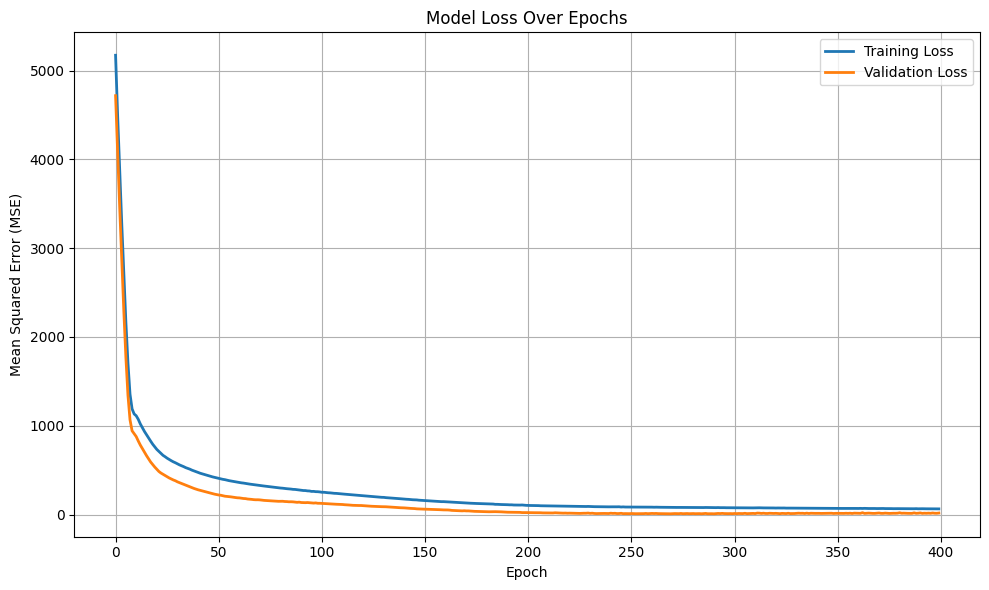

In [27]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Define model
model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dense(64, activation='relu'),
    Dense(1)  # Predicts Power
])

model.compile(optimizer='adam', loss='mse')

# Train model and store training history
history = model.fit(
    X_train, Y_train,
    epochs=400,
    validation_split=0.1,
    verbose=1
)

# 📈 Plot training & validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
# After training
model.save('pid_power_model.h5')

In [26]:
import numpy as np
import pandas as pd
import itertools
from tensorflow.keras.models import load_model


# Define fine-grained PID value ranges
kp_vals = np.linspace(1, 50, 80)
ki_vals = np.linspace(0, 10, 80)
kd_vals = np.linspace(0, 10, 80)

# Generate all 512,000 combinations
print("🔄 Generating PID combinations...")
pid_combinations = np.array(list(itertools.product(kp_vals, ki_vals, kd_vals)))

# Predict in batches to avoid memory issues
batch_size = 10000
predicted_power = []

print("⚡ Predicting power for 500k combinations...")
for i in range(0, len(pid_combinations), batch_size):
    batch = pid_combinations[i:i+batch_size]
    preds = model.predict(batch, verbose=0)
    predicted_power.append(preds)

# Concatenate predictions
predicted_power = np.vstack(predicted_power)

# Get best PID with max predicted power
best_index = np.argmax(predicted_power)
best_pid = pid_combinations[best_index]
best_power = predicted_power[best_index].item()

# Output
print(f"✅ Best PID parameters out of 500k:")
print(f"   ➤ Kp = {best_pid[0]:.3f}")
print(f"   ➤ Ki = {best_pid[1]:.3f}")
print(f"   ➤ Kd = {best_pid[2]:.3f}")
print(f"   ➤ Predicted Power = {best_power:.3f}")


🔄 Generating PID combinations...
⚡ Predicting power for 500k combinations...
✅ Best PID parameters out of 500k:
   ➤ Kp = 1.000
   ➤ Ki = 0.000
   ➤ Kd = 10.000
   ➤ Predicted Power = 188.420
